
# Gaia-Based Identification and Dynamical Characterization of the Globular Cluster M4

## Overview

This project uses **Gaia astrometric and photometric data** to isolate the globular cluster **M4**, estimate its distance, build a color-magnitude diagram, and analyze its projected stellar motions.

The project is designed as a portfolio-quality astrophysics analysis rather than a lab submission. It combines:
- **observational astrophysics** through Gaia data analysis,
- **Calculus III** through vector coordinates and projected motion in the tangent plane,
- **Calculus IV** through a dynamical toy model for bound stellar motion in the cluster core.

## Main questions

1. Can M4 be isolated from field stars using proper motion and parallax?
2. What distance does the Gaia parallax data imply for M4?
3. What does the cluster color-magnitude diagram reveal?
4. What does the observed proper-motion dispersion imply about internal cluster dynamics?

## Dataset

This notebook uses the file `m4.dat`, which contains a Gaia catalog query around M4 with the following columns:

1. RA in degrees  
2. Dec in degrees  
3. parallax in milliarcseconds  
4. parallax error in milliarcseconds  
5. proper motion in RA in milliarcseconds per year  
6. proper motion error in RA in milliarcseconds per year  
7. proper motion in Dec in milliarcseconds per year  
8. proper motion error in Dec in milliarcseconds per year  
9. G-band apparent magnitude  
10. G-band magnitude uncertainty  
11. B-band apparent magnitude  
12. B-band magnitude uncertainty  
13. R-band apparent magnitude  
14. R-band magnitude uncertainty


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5) #plot width for easy viewing
plt.rcParams["axes.grid"] = True #grid lines default


## 1. Load the Gaia dataset
The original `m4.dat` file contains a text header, so we skip the first 67 lines and then load the semicolon-separated table.


In [22]:
in_array = np.genfromtxt("m4.dat", skip_header=67, delimiter=";")

ra = in_array[:, 0]
dec = in_array[:, 1]
parallax = in_array[:, 2]
parallax_error = in_array[:, 3]
pmra = in_array[:, 4]
pmra_error = in_array[:, 5]
pmdec = in_array[:, 6]
pmdec_error = in_array[:, 7]
g_mag = in_array[:, 8]
g_mag_error = in_array[:, 9]
b_mag = in_array[:, 10]
b_mag_error = in_array[:, 11]
r_mag = in_array[:, 12]
r_mag_error = in_array[:, 13]

print(f"Number of stars in file: {len(ra):,}")

Number of stars in file: 104,734



## 2. Basic quality cuts

Gaia catalogs can include sources with negative parallaxes or large fractional uncertainties.  
For the main cluster analysis, I will keep track of a basic quality mask:
- finite astrometric and photometric values,
- positive parallax when a direct distance estimate is needed,
- manageable fractional parallax uncertainty.

I will still visualize the full sample first, because the M4 overdensity is easiest to identify in proper-motion space before aggressive cuts are applied.


In [23]:
quality = (np.isfinite(ra) & np.isfinite(dec) & np.isfinite(parallax) & np.isfinite(parallax_error) & np.isfinite(pmra) & np.isfinite(pmdec) &
    np.isfinite(g_mag) & np.isfinite(b_mag) & np.isfinite(r_mag))

frac_parallax_error = np.abs(parallax_error / np.where(parallax == 0, np.nan, parallax))
good_distance = quality & (parallax > 0) & np.isfinite(frac_parallax_error)

print(f"Usable sources for astrometric analysis: {np.sum(quality):,}")
print(f"Sources with positive parallax: {np.sum(good_distance):,}")

Usable sources for astrometric analysis: 102,433
Sources with positive parallax: 86,442



## 3. Proper-motion diagram for the full field

A globular cluster appears as a concentrated clump in proper-motion space because its stars share a common bulk motion across the sky.

In the plot below, the dense compact overdensity corresponds to **M4**.


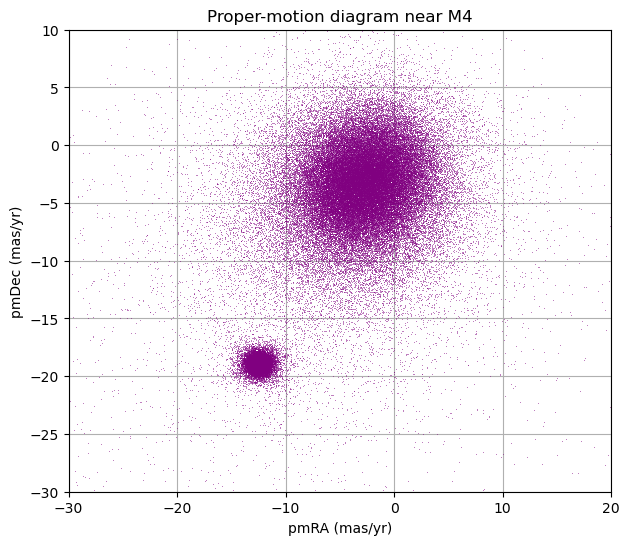

In [24]:
pm_plot_mask = quality & (pmra > -30) & (pmra < 20) & (pmdec > -30) & (pmdec < 10)

plt.figure(figsize=(7, 6))
plt.plot(pmra[pm_plot_mask], pmdec[pm_plot_mask], ",", alpha=0.5, color= 'purple')
plt.xlabel("pmRA (mas/yr)")
plt.ylabel("pmDec (mas/yr)")
plt.title("Proper-motion diagram near M4")
plt.xlim(-30, 20)
plt.ylim(-30, 10)
plt.show()


## 4. Define a proper-motion selection for M4

From the proper-motion diagram, the compact M4 clump is centered near:

- pmRA approximately -13 mas/yr
- pmDec approximately -19 mas/yr

I apply a rectangular cut to isolate the cluster candidate population.


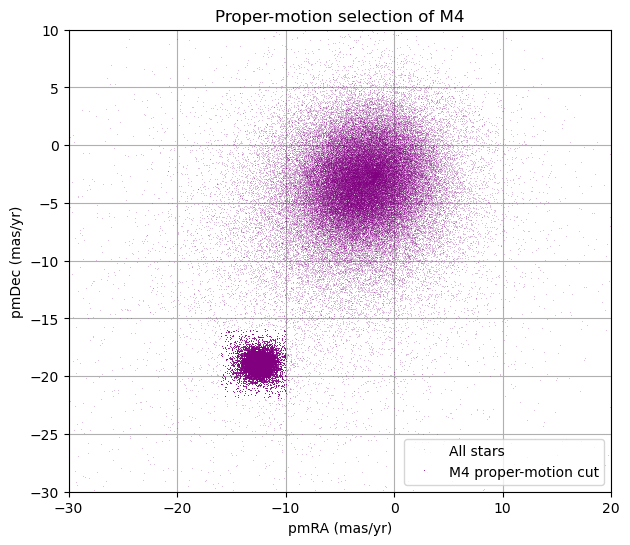

Stars passing proper-motion cut: 17,216


In [25]:
pm_cluster = (quality & (pmra > -16) & (pmra < -10) & (pmdec > -22) & (pmdec < -16))

plt.figure(figsize=(7, 6))
plt.plot(pmra[pm_plot_mask], pmdec[pm_plot_mask], ",", alpha=0.25, label="All stars", color='purple')
plt.plot(pmra[pm_cluster], pmdec[pm_cluster], ",", alpha=0.8, label="M4 proper-motion cut", color='purple')
plt.xlabel("pmRA (mas/yr)")
plt.ylabel("pmDec (mas/yr)")
plt.title("Proper-motion selection of M4")
plt.xlim(-30, 20)
plt.ylim(-30, 10)
plt.legend()
plt.show()

print(f"Stars passing proper-motion cut: {np.sum(pm_cluster):,}")


## 5. Add parallax and uncertainty cuts

Proper motion alone is not enough, because some field stars can have similar projected motions.  
To isolate M4 more cleanly, I add:

- a **parallax range** consistent with M4,
- a **fractional parallax error cut** of 20 percent.

The distance from a parallax measured in milliarcseconds is

$$d\ (\mathrm{pc}) = \frac{1000}{p_{\mathrm{mas}}}$$

This is accurate when the parallax is positive and reasonably well measured.


In [26]:
m4_mask = (pm_cluster & (parallax > 0.35) & (parallax < 0.70) & (frac_parallax_error < 0.20))

distance_pc = 1000.0 / parallax[m4_mask]

print(f"Stars in final M4 sample: {np.sum(m4_mask):,}")
print(f"Median parallax of M4 sample: {np.median(parallax[m4_mask]):.4f} mas")
print(f"Median distance of M4 sample: {np.median(distance_pc):.1f} pc")
print(f"Median distance of M4 sample: {np.median(distance_pc)/1000:.3f} kpc")

Stars in final M4 sample: 4,005
Median parallax of M4 sample: 0.5257 mas
Median distance of M4 sample: 1902.2 pc
Median distance of M4 sample: 1.902 kpc



## 6. Parallax distribution and cluster distance

The filtered sample should show a narrow parallax concentration.  
I use the **median parallax** and **median distance** as robust summaries.


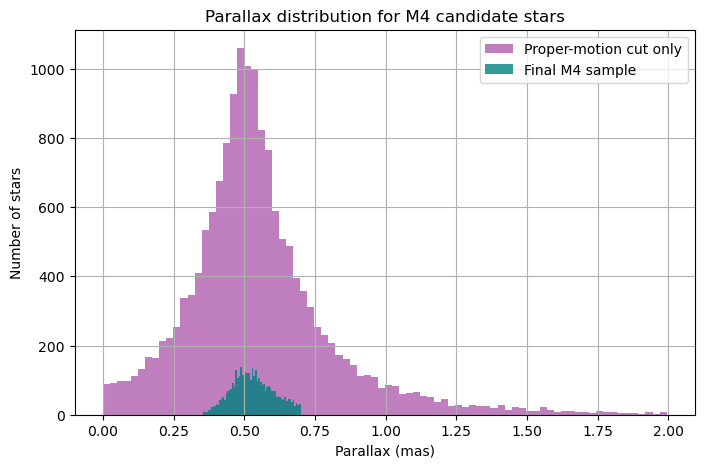

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(parallax[pm_cluster & (parallax > 0) & (parallax < 2.0)], bins=80, alpha=0.5, label="Proper-motion cut only", color='purple')
plt.hist(parallax[m4_mask], bins=60, alpha=0.8, label="Final M4 sample", color='teal')
plt.xlabel("Parallax (mas)")
plt.ylabel("Number of stars")
plt.title("Parallax distribution for M4 candidate stars")
plt.legend()
plt.show()


## 7. Apparent and absolute magnitudes

The Gaia distance estimate lets us convert apparent magnitude to absolute magnitude.

The distance modulus relation is

$$M_G = G - 5 \log_{10}(d) + 5$$

where:
- $M_G$ is the absolute G-band magnitude,
- $G$ is the apparent G-band magnitude,
- $d$ is the distance in parsecs.


In [28]:
full_good = quality & (parallax > 0) & (frac_parallax_error < 0.20)
distance_full_pc = 1000.0 / parallax[full_good]
M_G_full = g_mag[full_good] - 5*np.log10(distance_full_pc) + 5

distance_m4_pc = 1000.0 / parallax[m4_mask]
M_G_m4 = g_mag[m4_mask] - 5*np.log10(distance_m4_pc) + 5
color_m4 = b_mag[m4_mask] - r_mag[m4_mask]
color_full = b_mag[full_good] - r_mag[full_good]


## 8. Apparent magnitude versus distance

This plot shows the usual observational selection effect: distant stars are preferentially faint in apparent magnitude.


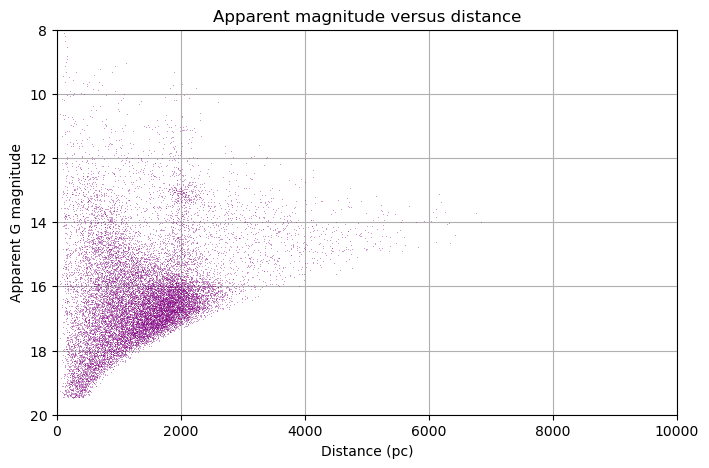

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(distance_full_pc, g_mag[full_good], ",", alpha=0.4, color='purple')
plt.xlabel("Distance (pc)")
plt.ylabel("Apparent G magnitude")
plt.title("Apparent magnitude versus distance")
plt.xlim(0, 10000)
plt.ylim(20, 8)
plt.show()


## 9. Color-magnitude diagram of the full quality sample

A color-magnitude diagram is a Hertzsprung-Russell-type diagram built from photometry and distance estimates.

I use:

$$\text{color} = B - R$$

and the G-band absolute magnitude.


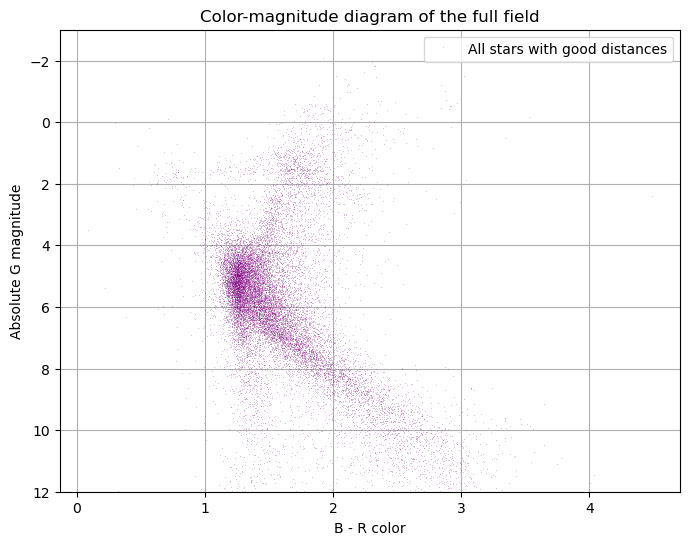

In [30]:
plt.figure(figsize=(8, 6))
plt.plot(color_full, M_G_full, ",", alpha=0.25, label="All stars with good distances", color='purple')
plt.xlabel("B - R color")
plt.ylabel("Absolute G magnitude")
plt.title("Color-magnitude diagram of the full field")
plt.ylim(12, -3)
plt.legend()
plt.show()


## 10. Color-magnitude diagram of M4

If the membership filtering worked, the cluster sequence should be much cleaner than the full field CMD because cluster stars have similar ages, distances, and chemical composition.


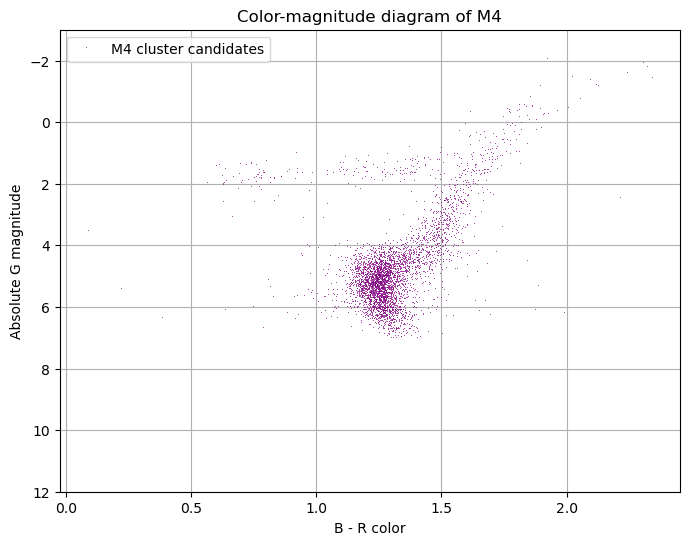

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(color_m4, M_G_m4, ",", alpha=0.7, label="M4 cluster candidates", color='purple')
plt.xlabel("B - R color")
plt.ylabel("Absolute G magnitude")
plt.title("Color-magnitude diagram of M4")
plt.ylim(12, -3)
plt.legend()
plt.show()


## 11. Calc III: projected position and velocity vectors

To make the analysis more physical, I now treat the cluster stars as vectors in the plane of the sky relative to the cluster center.

### Cluster-center definitions

I estimate the cluster center using median values from the selected sample:

$$\mathrm{RA}_{\mathrm{center}} = \mathrm{median}(\mathrm{RA})$$ 
$$\mathrm{Dec}_{\mathrm{center}} = \mathrm{median}(\mathrm{Dec})$$

The small-angle tangent-plane coordinates are

$$x = d\,(\mathrm{RA} - \mathrm{RA}_{\mathrm{center}})\cos(\mathrm{Dec}_{\mathrm{center}})$$ 
$$y = d\,(\mathrm{Dec} - \mathrm{Dec}_{\mathrm{center}})$$

with angular quantities expressed in radians.

These produce projected positions in parsecs.

For projected velocities, I use the standard conversion

$$v_t = 4.74047 \,\mu\, d$$

where the proper-motion offsets are measured relative to the cluster mean motion.


In [32]:
ra_center = np.median(ra[m4_mask])
dec_center = np.median(dec[m4_mask])
parallax_center = np.median(parallax[m4_mask])
distance_center_pc = np.median(distance_m4_pc)

pmra_center = np.median(pmra[m4_mask])
pmdec_center = np.median(pmdec[m4_mask])

ra_offset_rad = np.deg2rad(ra[m4_mask] - ra_center) * np.cos(np.deg2rad(dec_center))
dec_offset_rad = np.deg2rad(dec[m4_mask] - dec_center)

x_pc = distance_center_pc * ra_offset_rad
y_pc = distance_center_pc * dec_offset_rad

distance_center_kpc = distance_center_pc / 1000.0
vx_kms = 4.74047 * (pmra[m4_mask] - pmra_center) * distance_center_kpc
vy_kms = 4.74047 * (pmdec[m4_mask] - pmdec_center) * distance_center_kpc

r_proj_pc = np.sqrt(x_pc**2 + y_pc**2)
v_proj_kms = np.sqrt(vx_kms**2 + vy_kms**2)

print(f"Estimated cluster center RA: {ra_center:.4f} deg")
print(f"Estimated cluster center Dec: {dec_center:.4f} deg")
print(f"Cluster mean pmRA: {pmra_center:.3f} mas/yr")
print(f"Cluster mean pmDec: {pmdec_center:.3f} mas/yr")

Estimated cluster center RA: 245.8961 deg
Estimated cluster center Dec: -26.5214 deg
Cluster mean pmRA: -12.493 mas/yr
Cluster mean pmDec: -19.002 mas/yr


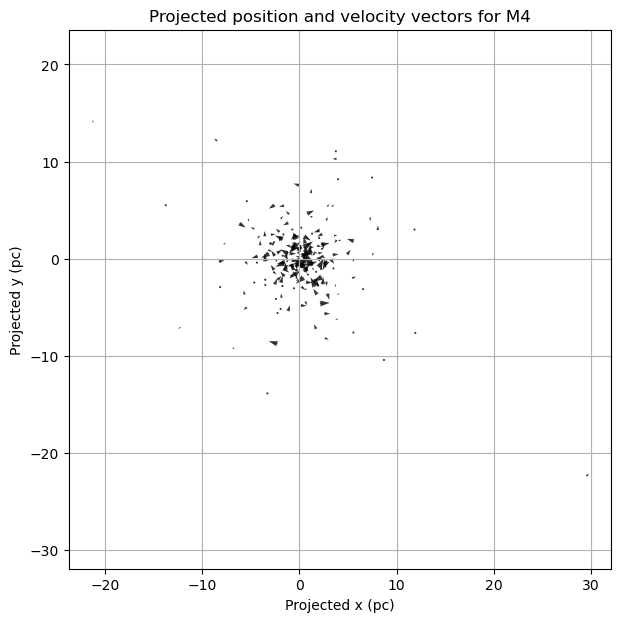

In [33]:
plt.figure(figsize=(7, 7))
plt.quiver(x_pc[::20], y_pc[::20], vx_kms[::20], vy_kms[::20], angles="xy", scale_units="xy", scale=10, alpha=0.8)
plt.xlabel("Projected x (pc)")
plt.ylabel("Projected y (pc)")
plt.title("Projected position and velocity vectors for M4")
plt.axis("equal")
plt.show()


## 12. Dynamical summary from the Gaia sample

A useful first characterization is the projected dispersion in position and velocity.

I define:
- $\sigma_r$ from the spread in projected positions,
- $\sigma_v$ from the spread in projected velocities relative to the cluster mean.

These are not full three-dimensional dispersions, but they give a physically meaningful projected dynamical scale.


In [34]:
sigma_r = np.sqrt(np.var(x_pc) + np.var(y_pc))
sigma_v = np.sqrt(np.var(vx_kms) + np.var(vy_kms))

print(f"Projected spatial dispersion sigma_r: {sigma_r:.3f} pc")
print(f"Projected velocity dispersion sigma_v: {sigma_v:.3f} km/s")
print(f"Median projected radius: {np.median(r_proj_pc):.3f} pc")
print(f"90th percentile projected radius: {np.percentile(r_proj_pc, 90):.3f} pc")

Projected spatial dispersion sigma_r: 5.389 pc
Projected velocity dispersion sigma_v: 6.104 km/s
Median projected radius: 2.991 pc
90th percentile projected radius: 7.980 pc



## 13. Calc IV: a linearized dynamical toy model for bound cluster motion

A full globular-cluster dynamical model is far beyond the scope of this notebook.  
However, near the central region of a bound system, the restoring force can be approximated as linear in displacement. That leads to the two-dimensional system

$$\frac{dx}{dt} = v_x$$
$$\frac{dy}{dt} = v_y$$  
$$\frac{dv_x}{dt} = -\omega^2 x$$ 
$$\frac{dv_y}{dt} = -\omega^2 y$$

This is the vector form of a two-dimensional harmonic oscillator. It is a **local toy model**, not a full cluster orbit model.

A natural characteristic frequency comes from the observed scales:

$\omega \approx \frac{\sigma_v}{\sigma_r}$ after converting $\sigma_v$ from km/s to pc/Myr.

This gives a physically motivated timescale for bound motion in the cluster core.


In [35]:
#converts km/s to pc/Myr
km_s_to_pc_myr = 1.0227121650537077
sigma_v_pc_myr = sigma_v * km_s_to_pc_myr

omega = sigma_v_pc_myr / sigma_r #1/Myr
period_myr = 2 * np.pi / omega

print(f"sigma_v = {sigma_v_pc_myr:.3f} pc/Myr")
print(f"Estimated angular frequency omega: {omega:.3f} 1/Myr")
print(f"Characteristic oscillation period: {period_myr:.3f} Myr")

sigma_v = 6.242 pc/Myr
Estimated angular frequency omega: 1.158 1/Myr
Characteristic oscillation period: 5.425 Myr



### RK4 numerical integration

I now integrate the toy-model equations using a fourth-order Runge-Kutta method.
This is the Calculus IV component of the project: the notebook solves a coupled first-order ODE system numerically.


In [36]:
def rhs(state, omega):
    x, y, vx, vy = state
    ax = -(omega**2) * x
    ay = -(omega**2) * y
    return np.array([vx, vy, ax, ay], dtype=float)

def rk4_step(state, dt, omega):
    k1 = rhs(state, omega)
    k2 = rhs(state + 0.5*dt*k1, omega)
    k3 = rhs(state + 0.5*dt*k2, omega)
    k4 = rhs(state + dt*k3, omega)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

#representative initial state based on typical observed scales
state0 = np.array([np.median(r_proj_pc), 0.0, 0.0, sigma_v_pc_myr])

t_max = 3.0 * period_myr
dt = period_myr / 1000.0
n_steps = int(t_max / dt)

times = np.zeros(n_steps + 1)
states = np.zeros((n_steps + 1, 4))
states[0] = state0

for i in range(n_steps):
    states[i + 1] = rk4_step(states[i], dt, omega)
    times[i + 1] = times[i] + dt

x_model = states[:, 0]
y_model = states[:, 1]
vx_model = states[:, 2]
vy_model = states[:, 3]

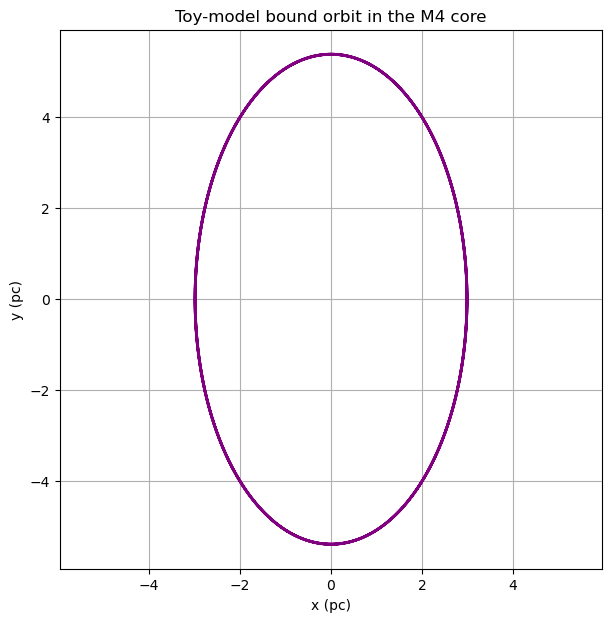

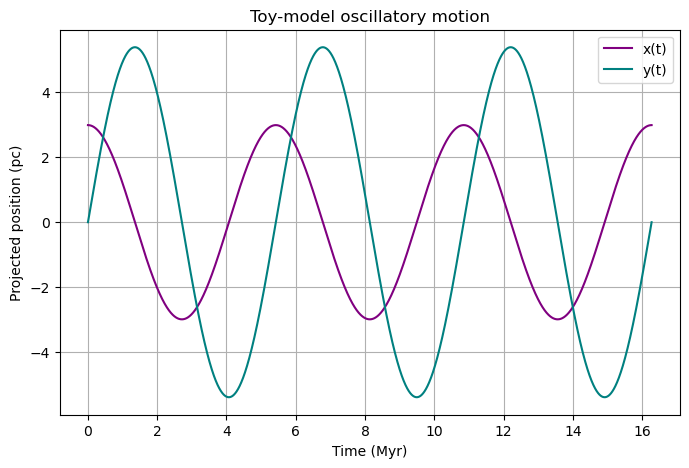

In [37]:
plt.figure(figsize=(7, 7))
plt.plot(x_model, y_model, lw=2, color='purple')
plt.xlabel("x (pc)")
plt.ylabel("y (pc)")
plt.title("Toy-model bound orbit in the M4 core")
plt.axis("equal")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(times, x_model, label="x(t)", color='purple')
plt.plot(times, y_model, label="y(t)", color='teal')
plt.xlabel("Time (Myr)")
plt.ylabel("Projected position (pc)")
plt.title("Toy-model oscillatory motion")
plt.legend()
plt.show()


## 14. Physical interpretation

This project shows that M4 can be isolated very clearly using **Gaia proper motion plus parallax information**.

The resulting cluster CMD is much cleaner than the full-field CMD, which is what we expect for a real globular cluster:
- stars are at nearly the same distance,
- they formed at approximately the same time,
- they trace a coherent stellar population.

The dynamical section adds a physically motivated interpretation:
- the observed proper-motion dispersion gives a characteristic internal speed scale,
- the projected spatial extent gives a characteristic size scale,
- together they define a natural dynamical timescale.

The ODE integration is intentionally a simplified local model, but it connects the observed Gaia kinematics to upper-level stellar-dynamics ideas in a mathematically clear way.



## 15. Final results table


In [39]:
results = pd.DataFrame({
    "Quantity": ["Stars in final M4 sample", "Median parallax", "Median distance", "Cluster center RA", "Cluster center Dec",
        "Mean pmRA", "Mean pmDec", "Projected spatial dispersion sigma_r", "Projected velocity dispersion sigma_v",
        "Toy-model angular frequency omega", "Toy-model oscillation period"],
    "Value": [np.sum(m4_mask), np.median(parallax[m4_mask]), np.median(distance_m4_pc), ra_center, dec_center, pmra_center, pmdec_center,
        sigma_r, sigma_v, omega, period_myr],
    "Units": ["stars", "mas", "pc", "deg", "deg", "mas/yr", "mas/yr", "pc", "km/s", "1/Myr", "Myr" ]})

results

,Quantity,Value,Units
0,Stars in final M4 sample,4005.000000,stars
1,Median parallax,0.525700,mas
2,Median distance,1902.225604,pc
3,Cluster center RA,245.896057,deg
4,Cluster center Dec,-26.521357,deg
5,Mean pmRA,-12.493000,mas/yr
6,Mean pmDec,-19.002000,mas/yr
7,Projected spatial dispersion sigma_r,5.389160,pc
8,Projected velocity dispersion sigma_v,6.103517,km/s
9,Toy-model angular frequency omega,1.158277,1/Myr



## 16. Limitations and future work

### Limitations
- The membership selection is based on simple rectangular cuts, not a probabilistic clustering algorithm.
- Distances are estimated from inverse parallax, which becomes biased for large fractional errors. I reduced that issue by applying a 20 percent fractional-error cut.
- The dynamical model is a **local harmonic approximation**, not a full N-body or Jeans analysis.
- Only projected motions are available here; full three-dimensional velocities would require radial-velocity data as well.

### Future work
- Use Gaussian mixture modeling or DBSCAN for membership classification.
- Compare M4 with a field-star control sample more formally.
- Add radial-velocity data to build a fuller dynamical picture.
- Fit isochrones to the cluster CMD to estimate age and metallicity.



## 17. Conclusion

Using Gaia astrometry and photometry, I isolated the globular cluster M4, estimated its distance, constructed its color-magnitude diagram, and characterized its projected kinematics.

This project connects:
- **observational astrophysics** through cluster identification and CMD analysis,
- **Calculus III** through projected position and velocity vectors,
- **Calculus IV** through numerical integration of a coupled dynamical ODE system.
